# Análise Exploratória — Indicador Criança Alfabetizada
### Tech Challenge Fase 3 — Predição e Inteligência Analítica para Alfabetização no Brasil

**Objetivo desta análise:** compreender o comportamento da camada Gold (Fase 2), identificar
padrões, distribuições, correlações e formular hipóteses que orientem a etapa de modelagem
supervisionada.

**Fonte dos dados:** BigQuery `tech-challenge-2-fiap-joao.gold_alfabetizacao`.

**Granularidade real dos dados:** município × ano (2021–2024). Não há dado no nível de aluno
individual na camada Gold — por isso o problema de predição será reformulado no notebook de
modelagem para o nível de município (ver `02_modelagem.ipynb`).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (10, 5)

RAW = "../data/raw"
df = pd.read_parquet(f"{RAW}/indicador_alfabetizacao_municipio.parquet")
df_brasil = pd.read_parquet(f"{RAW}/evolucao_temporal_brasil.parquet").sort_values("ano")
df_regiao = pd.read_parquet(f"{RAW}/evolucao_temporal_regiao.parquet").sort_values(["regiao","ano"])
df_uf = pd.read_parquet(f"{RAW}/evolucao_temporal_uf.parquet").sort_values(["sigla_uf","ano"])
df_metas_mun = pd.read_parquet(f"{RAW}/metas_vs_resultados_municipio.parquet")

df.shape

(2049, 12)

## 1. Visão geral da base município-ano

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2049 entries, 0 to 2048
Data columns (total 12 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   ano                                 2049 non-null   Int64  
 1   id_municipio                        2049 non-null   Int64  
 2   nome_municipio                      2049 non-null   str    
 3   sigla_uf                            2049 non-null   str    
 4   nome_uf                             2049 non-null   str    
 5   regiao                              2049 non-null   str    
 6   indicador_alfabetizacao_percentual  2049 non-null   float64
 7   proficiencia_media_saeb             2049 non-null   float64
 8   total_estudantes_avaliados          2049 non-null   Int64  
 9   total_escolas_avaliadas             2049 non-null   Int64  
 10  meta_percentual                     2048 non-null   float64
 11  gap_meta_percentual                 2048 non-null   fl

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ano,2049.0,2022.50122,1.119397,2021.0,2022.0,2023.0,2024.0,2025.0
id_municipio,2049.0,2856096.066374,1215575.788006,1100015.0,1718501.0,2701902.0,3530201.0,5300108.0
indicador_alfabetizacao_percentual,2049.0,48.582382,12.408978,18.2,39.1,47.4,57.1,87.0
proficiencia_media_saeb,2049.0,756.880966,27.760775,689.8,736.7,754.7,775.4,839.7
total_estudantes_avaliados,2049.0,235.534895,95.198107,30.0,163.0,228.0,303.0,552.0
total_escolas_avaliadas,2049.0,3.496828,1.13111,1.0,2.0,3.0,5.0,5.0
meta_percentual,2048.0,54.15,6.821673,45.0,49.575,54.15,58.725,63.3
gap_meta_percentual,2048.0,-5.570752,10.886491,-27.1,-14.3,-8.5,3.5,28.2


In [4]:
print("Município-ano únicos:", df[["id_municipio","ano"]].drop_duplicates().shape[0])
print("Municípios distintos:", df["id_municipio"].nunique())
print("Anos disponíveis:", sorted(df["ano"].unique()))
print()
print("Valores nulos por coluna:")
df.isna().sum()

Município-ano únicos: 2049
Municípios distintos: 513
Anos disponíveis: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]

Valores nulos por coluna:


ano                                   0
id_municipio                          0
nome_municipio                        0
sigla_uf                              0
nome_uf                               0
regiao                                0
indicador_alfabetizacao_percentual    0
proficiencia_media_saeb               0
total_estudantes_avaliados            0
total_escolas_avaliadas               0
meta_percentual                       1
gap_meta_percentual                   1
dtype: int64

**Observação:** a base cobre ~512 municípios (amostra, não o universo de ~5.570 municípios
brasileiros) em 4 anos completos (2021–2024), com 1 registro adicional de 2025 (ano incompleto,
será descartado da modelagem). Há poucos nulos, concentrados em `meta_percentual` /
`gap_meta_percentual` (1 registro cada).

## 2. Evolução temporal do indicador (Brasil, região, UF)

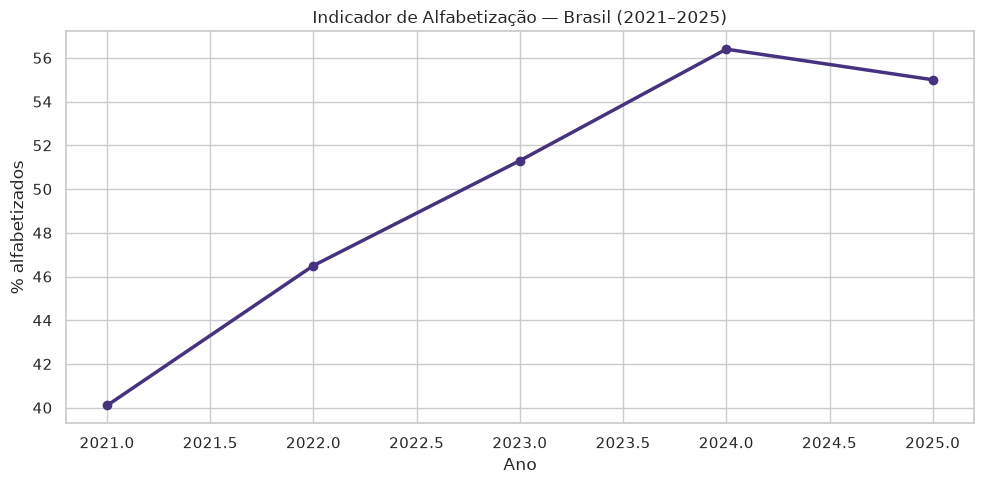

In [5]:
fig, ax = plt.subplots()
ax.plot(df_brasil["ano"], df_brasil["indicador_alfabetizacao_percentual"], marker="o", linewidth=2.5)
ax.set_title("Indicador de Alfabetização — Brasil (2021–2025)")
ax.set_xlabel("Ano")
ax.set_ylabel("% alfabetizados")
plt.tight_layout()
plt.savefig("../images/evolucao_brasil.png", dpi=120)
plt.show()

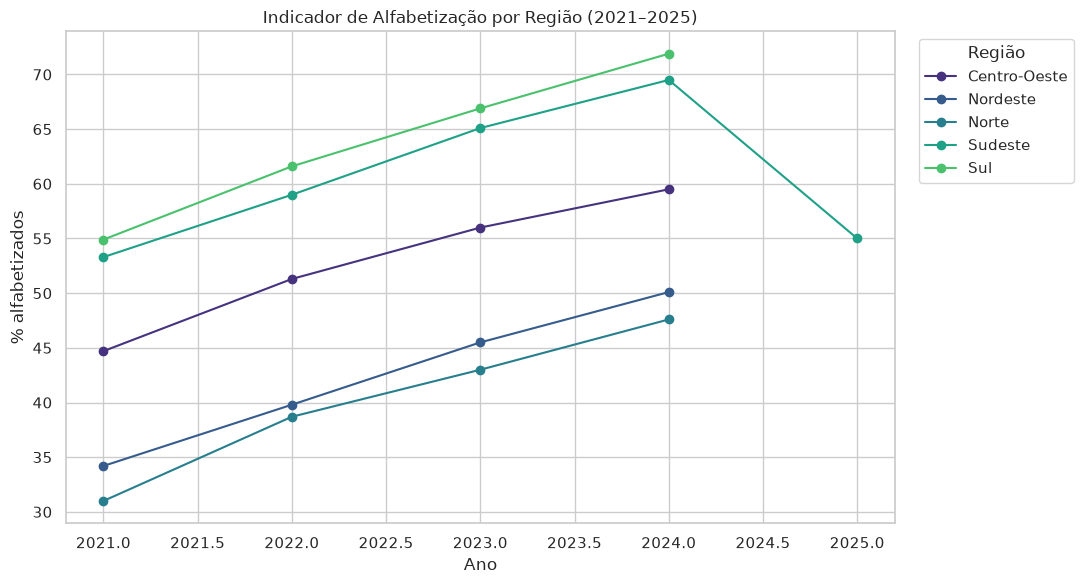

In [6]:
fig, ax = plt.subplots(figsize=(11,6))
for regiao, grp in df_regiao.groupby("regiao"):
    ax.plot(grp["ano"], grp["indicador_alfabetizacao_percentual"], marker="o", label=regiao)
ax.set_title("Indicador de Alfabetização por Região (2021–2025)")
ax.set_xlabel("Ano"); ax.set_ylabel("% alfabetizados")
ax.legend(title="Região", bbox_to_anchor=(1.02,1), loc="upper left")
plt.tight_layout()
plt.savefig("../images/evolucao_regiao.png", dpi=120)
plt.show()

**Hipótese H1:** existe disparidade regional persistente no indicador de alfabetização
(regiões Norte/Nordeste historicamente abaixo de Sul/Sudeste). Se confirmada, `regiao`/`sigla_uf`
devem ser features relevantes no modelo.

## 3. Distribuição do indicador e da meta por ano

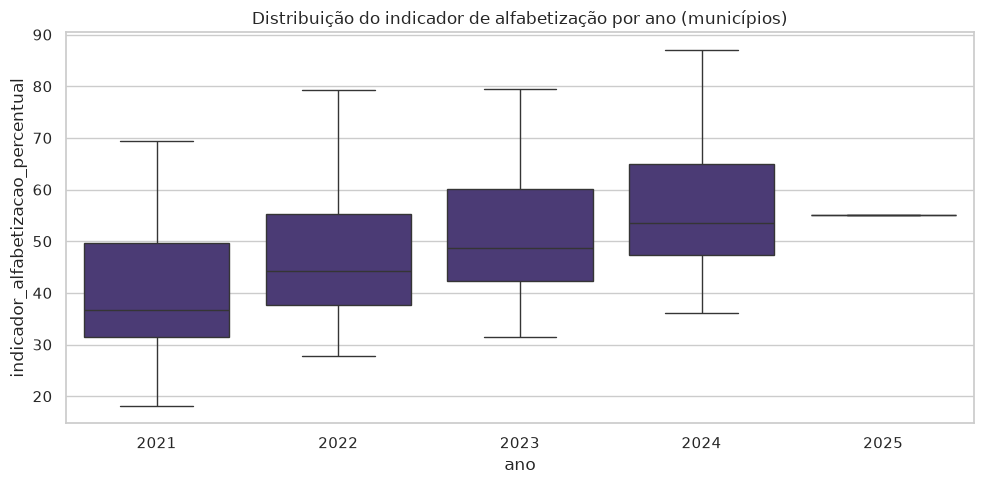

In [7]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x="ano", y="indicador_alfabetizacao_percentual", ax=ax)
ax.set_title("Distribuição do indicador de alfabetização por ano (municípios)")
plt.tight_layout()
plt.savefig("../images/boxplot_indicador_ano.png", dpi=120)
plt.show()

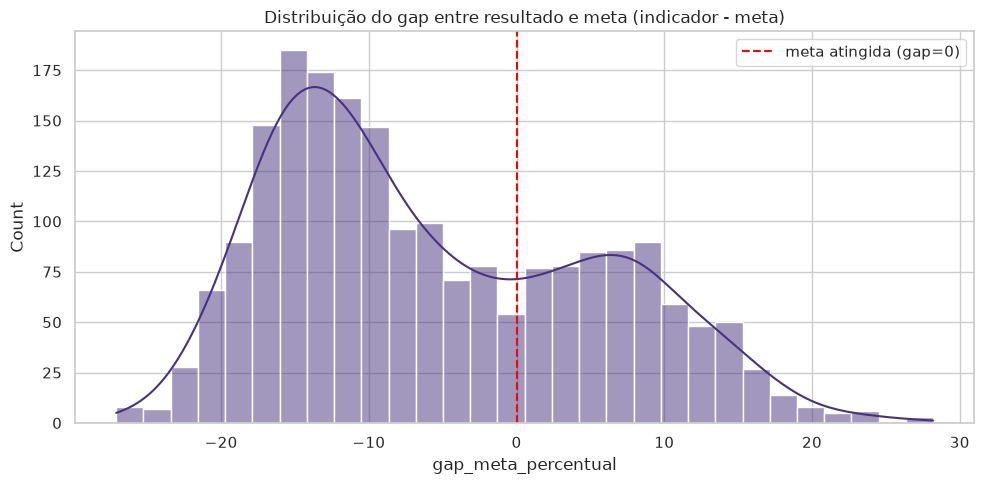

Taxa de municípios que atingiram a meta no período: 31.8%


In [8]:
fig, ax = plt.subplots()
sns.histplot(df["gap_meta_percentual"], bins=30, kde=True, ax=ax)
ax.axvline(0, color="red", linestyle="--", label="meta atingida (gap=0)")
ax.set_title("Distribuição do gap entre resultado e meta (indicador - meta)")
ax.legend()
plt.tight_layout()
plt.savefig("../images/dist_gap.png", dpi=120)
plt.show()

taxa_atingimento = (df["gap_meta_percentual"] >= 0).mean()
print(f"Taxa de municípios que atingiram a meta no período: {taxa_atingimento:.1%}")

**Observação:** apenas ~31% dos município-ano atingiram a meta estipulada — alvo
desbalanceado (será tratado na modelagem com `class_weight='balanced'` e métricas robustas a
desbalanceamento: F1, ROC-AUC, PR-AUC, em vez de acurácia pura).

## 4. Correlações entre variáveis numéricas

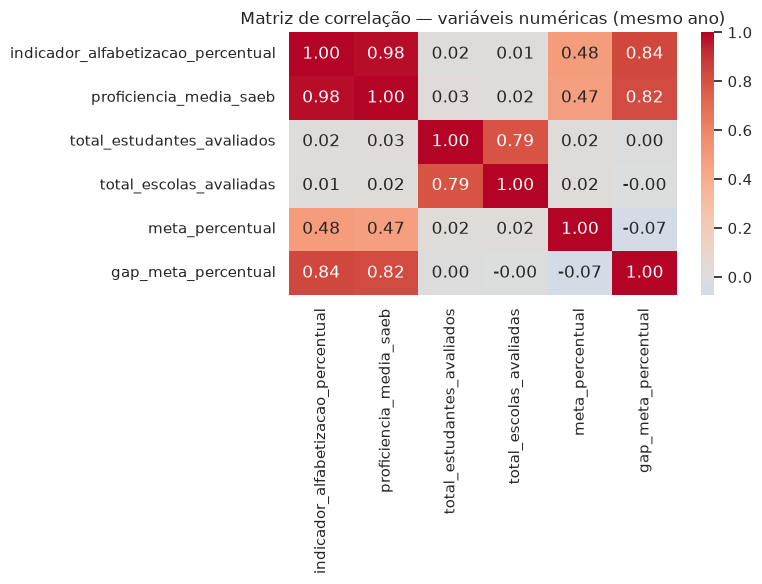

In [9]:
num_cols = ["indicador_alfabetizacao_percentual","proficiencia_media_saeb",
            "total_estudantes_avaliados","total_escolas_avaliadas",
            "meta_percentual","gap_meta_percentual"]
corr = df[num_cols].corr()
fig, ax = plt.subplots(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Matriz de correlação — variáveis numéricas (mesmo ano)")
plt.tight_layout()
plt.savefig("../images/heatmap_correlacao.png", dpi=120)
plt.show()

**Hipótese H2 (confirmada) — Risco de Data Leakage:** `proficiencia_media_saeb` tem
correlação forte com `indicador_alfabetizacao_percentual` (mesma fonte/mesmo ano) e
`gap_meta_percentual` é definido algebricamente como `indicador - meta`. Usar essas três
variáveis do **mesmo ano** como features para prever se a meta foi atingida seria vazamento de
dado (o "resultado" estaria dentro das features). **Decisão:** essas colunas serão excluídas do
ano corrente e substituídas por versões defasadas (ano anterior) na engenharia de atributos —
ver `src/preprocessing/build_features.py`.

## 5. Indicador por região e UF (nível mais granular)

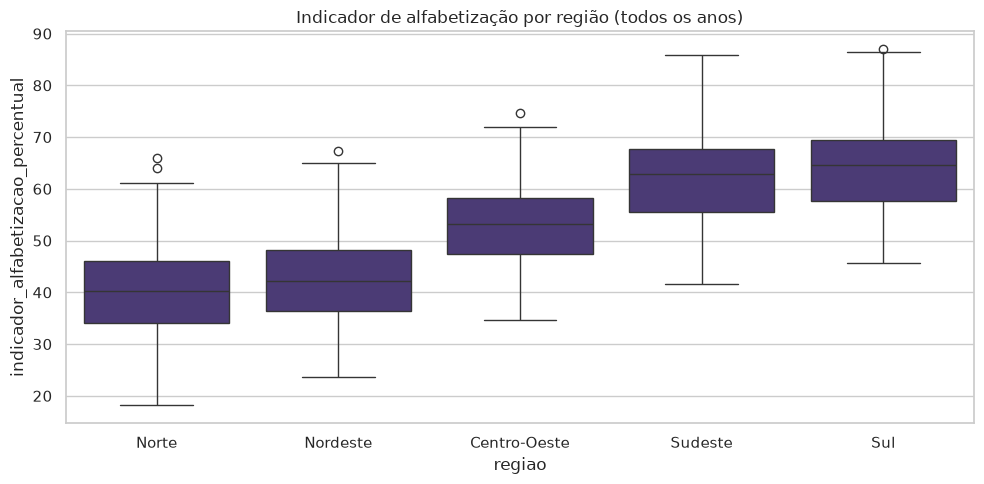

In [10]:
fig, ax = plt.subplots(figsize=(10,5))
ordem = df.groupby("regiao")["indicador_alfabetizacao_percentual"].median().sort_values().index
sns.boxplot(data=df, x="regiao", y="indicador_alfabetizacao_percentual", order=ordem, ax=ax)
ax.set_title("Indicador de alfabetização por região (todos os anos)")
plt.tight_layout()
plt.savefig("../images/boxplot_regiao.png", dpi=120)
plt.show()

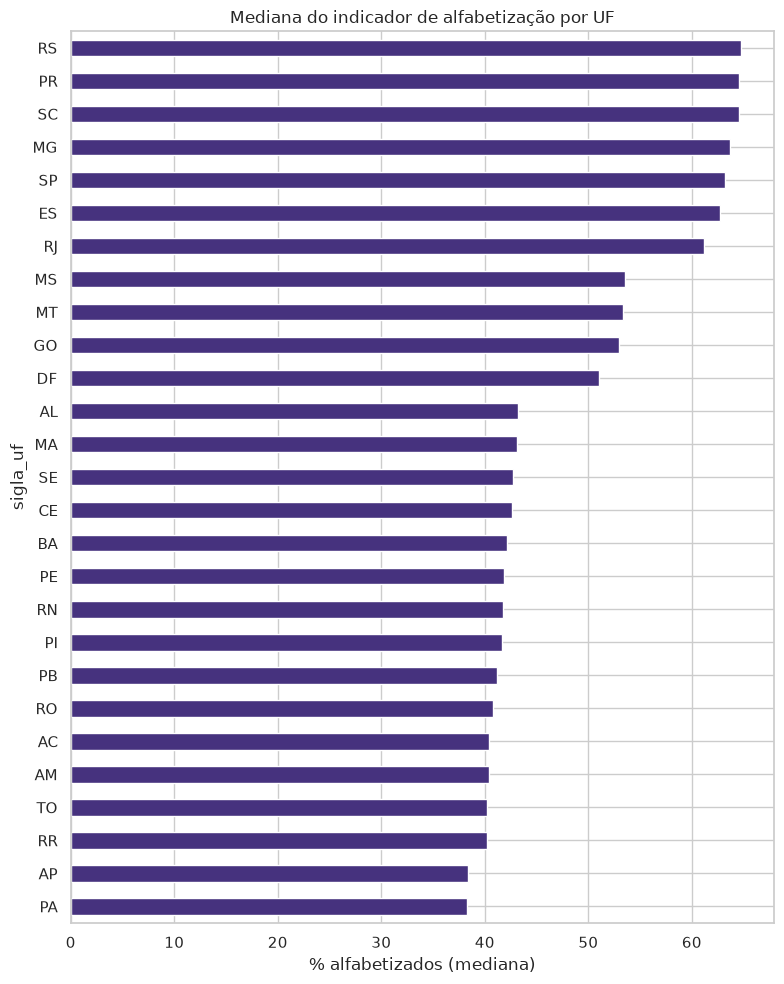

In [11]:
top_uf = df.groupby("sigla_uf")["indicador_alfabetizacao_percentual"].median().sort_values()
fig, ax = plt.subplots(figsize=(8,10))
top_uf.plot(kind="barh", ax=ax)
ax.set_title("Mediana do indicador de alfabetização por UF")
ax.set_xlabel("% alfabetizados (mediana)")
plt.tight_layout()
plt.savefig("../images/barh_uf.png", dpi=120)
plt.show()

## 6. Relação entre escala do sistema escolar e desempenho

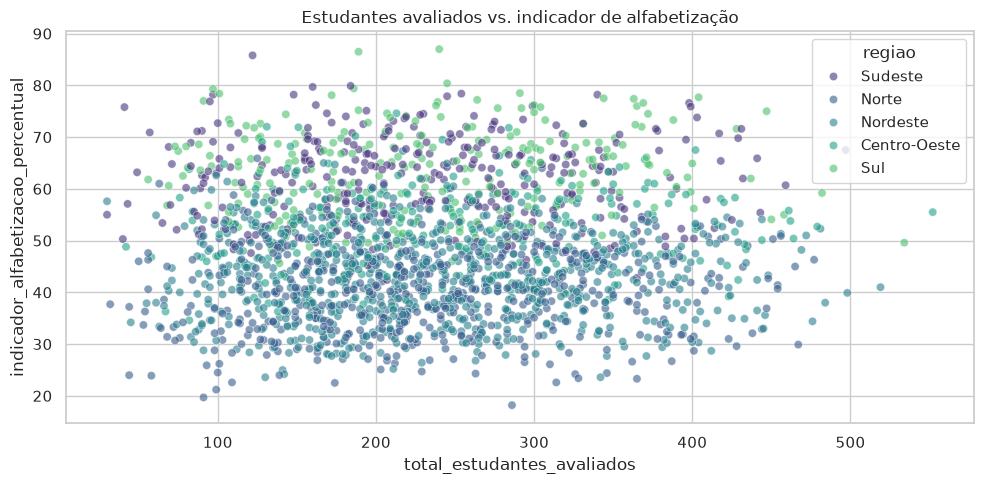

Correlação estudantes avaliados x indicador: 0.016


In [12]:
fig, ax = plt.subplots()
sns.scatterplot(data=df, x="total_estudantes_avaliados", y="indicador_alfabetizacao_percentual",
                 hue="regiao", alpha=0.6, ax=ax)
ax.set_title("Estudantes avaliados vs. indicador de alfabetização")
plt.tight_layout()
plt.savefig("../images/scatter_estudantes.png", dpi=120)
plt.show()

print("Correlação estudantes avaliados x indicador:",
      df[["total_estudantes_avaliados","indicador_alfabetizacao_percentual"]].corr().iloc[0,1].round(3))

**Hipótese H3:** o porte do sistema escolar municipal (nº de estudantes/escolas avaliadas)
tem correlação fraca com o indicador — sugere que fatores territoriais/regionais pesam mais que
escala pura. Ainda assim, mantemos essas variáveis como features de contexto (não são
"vazadoras": representam a exposição/tamanho do sistema, não o resultado).

## 7. Persistência temporal (autocorrelação) — municípios tendem a se manter no mesmo patamar?

In [13]:
pivot = df.pivot_table(index="id_municipio", columns="ano", values="indicador_alfabetizacao_percentual")
corr_ano_a_ano = pivot[[2021,2022]].corr().iloc[0,1], pivot[[2022,2023]].corr().iloc[0,1], pivot[[2023,2024]].corr().iloc[0,1]
print("Correlação indicador ano N vs N+1:")
for anos, c in zip(["2021-2022","2022-2023","2023-2024"], corr_ano_a_ano):
    print(f"  {anos}: {c:.3f}")

Correlação indicador ano N vs N+1:
  2021-2022: 0.760
  2022-2023: 0.778
  2023-2024: 0.776


**Hipótese H4 (chave para a modelagem):** há forte autocorrelação temporal — o desempenho
de um município em um ano é um bom preditor do ano seguinte. Isso justifica a criação de
**features defasadas (lag)** como principal fonte de sinal preditivo não-vazador (município que
já vinha bem/mal tende a repetir o padrão), em vez de depender apenas de covariáveis estáticas.

## 8. Síntese das hipóteses e decisões de modelagem

| # | Hipótese | Evidência | Decisão de modelagem |
|---|----------|-----------|------------------------|
| H1 | Disparidade regional persistente | Boxplot por região/UF mostra gap claro Norte/Nordeste vs Sul/Sudeste | Incluir `regiao`, `sigla_uf` como features categóricas |
| H2 | `proficiencia_media_saeb` e `gap_meta_percentual` do mesmo ano vazam o alvo | Correlação alta / definição algébrica direta | Excluir do ano corrente; usar versões `_lag1` |
| H3 | Escala do sistema escolar tem baixa correlação isolada | Scatter com correlação fraca | Manter como feature de contexto, não descartar |
| H4 | Forte autocorrelação temporal ano-a-ano | Correlação >0.7 entre indicador(N) e indicador(N+1) | Criar features `_lag1` e `indicador_tendencia_lag1` como principal fonte preditiva |
| H5 | Alvo desbalanceado (~31% atingem meta) | Distribuição do gap | Usar `class_weight='balanced'`, métricas F1/ROC-AUC/PR-AUC, não acurácia |

Essas decisões alimentam diretamente a pipeline construída em
`src/preprocessing/build_features.py` e `src/modeling/`.